In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

Número de tornillos: 2


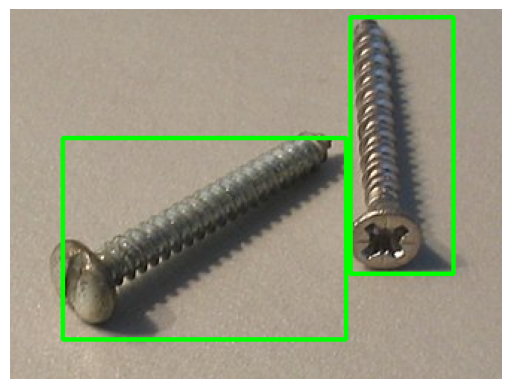

In [ ]:
img = cv2.imread("img/tornillos.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# suavizado
blur = cv2.GaussianBlur(gray,(5,5),0)

# umbral
_, thresh = cv2.threshold(blur,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# invertir si  son obscuros
thresh = cv2.bitwise_not(thresh)

# separar objetos
kernel = np.ones((3,3),np.uint8)
erode = cv2.erode(thresh,kernel,iterations=1)
dilate = cv2.dilate(erode,kernel,iterations=1)

# conectividad
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(dilate)

count = 0
area_min = 200

output = img.copy()

for i in range(1,num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > area_min:

        count += 1

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

print("Número de tornillos:",count)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Número de tornillos: 11


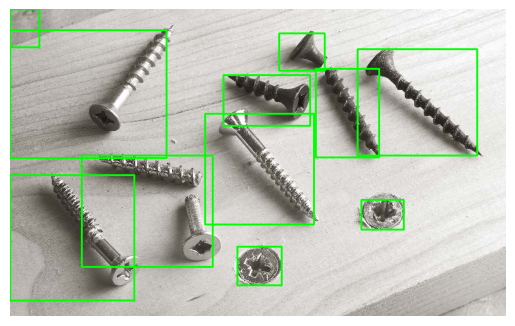

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("img/tornillos_2.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# suavizado
blur = cv2.GaussianBlur(gray,(5,5),0)

# umbral
_, thresh = cv2.threshold(blur,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# invertir
thresh = cv2.bitwise_not(thresh)

# cerrar huecos (une partes del tornillo)
kernel = np.ones((7,7),np.uint8)
close = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# eliminar ruido pequeño
open_img = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel)

# conectividad
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(open_img)

count = 0
area_min = 1200   

output = img.copy()

for i in range(1,num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > area_min:

        count += 1

        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]

        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

print("Número de tornillos:",count)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

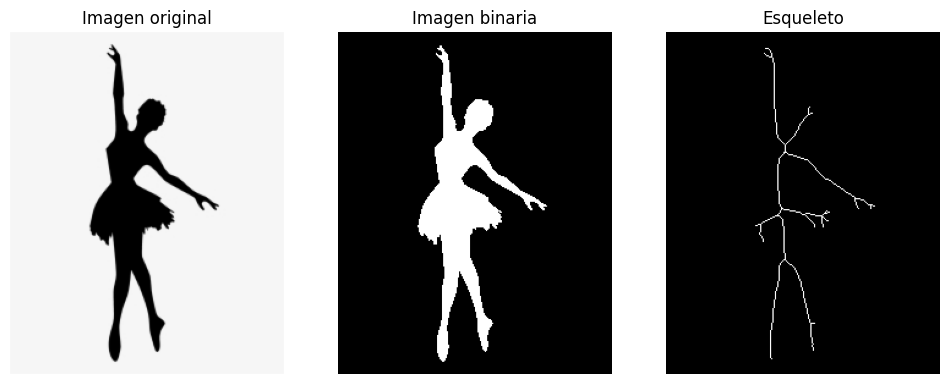

In [9]:
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

img = cv2.imread("img/bailarina.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invertir imagen
thresh_inv = cv2.bitwise_not(thresh)

binary = thresh_inv // 255

skeleton = skeletonize(binary)

# Convertir BGR a RGB para mostrar correctamente
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(thresh_inv, cmap="gray")
plt.title("Imagen binaria")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(skeleton, cmap="gray")
plt.title("Esqueleto")
plt.axis("off")

plt.show()

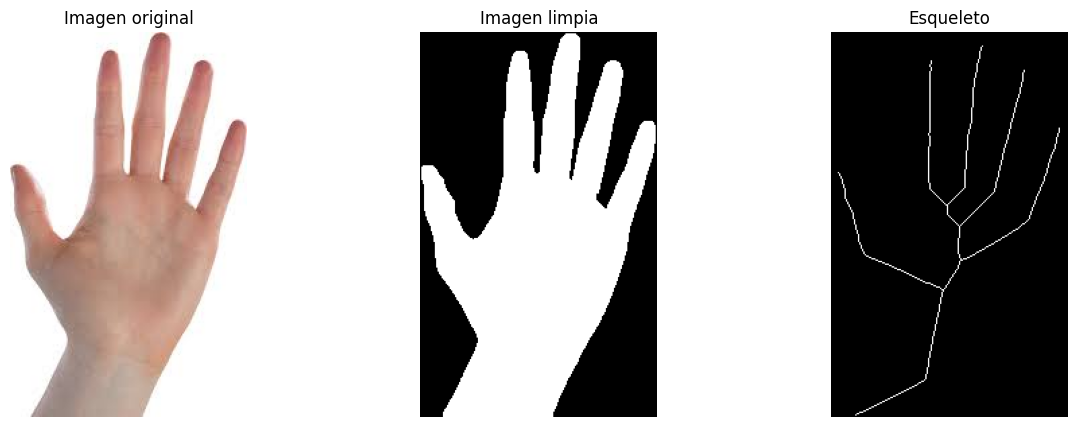

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

img = cv2.imread("img/mano.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

thresh_inv = cv2.bitwise_not(thresh)

# Limpieza morfológica
kernel = np.ones((5,5),np.uint8)

clean = cv2.morphologyEx(thresh_inv, cv2.MORPH_OPEN, kernel)

binary = clean // 255

skeleton = skeletonize(binary)

# Convertir para mostrar bien los colores
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(clean, cmap="gray")
plt.title("Imagen limpia")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(skeleton, cmap="gray")
plt.title("Esqueleto")
plt.axis("off")

plt.show()